# Análisis de errores e interpretabilidad

**TFM:** estimación de riesgo de mercado — target `target_risk_20d`.

Este notebook interpreta los resultados de los Notebooks 04 y 05 **sin cambiar** target, splits ni usar test para selección.

- Métricas agregadas, brecha validation→test, falsos positivos/negativos.
- Estabilidad temporal, VIX como score continuo, importancias globales y SHAP (si disponible).


## 0. Librerías, rutas y configuraciones fijas de modelos

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception:
    xgb = None
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    shap = None
    SHAP_AVAILABLE = False

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

MODELING_DIR = PROJECT_ROOT / "data" / "processed" / "modeling"
REPORTS_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target_risk_20d"
RANDOM_STATE = 42

LEVEL_FEATURES = [
    "sp500_close", "sp500_rolling_max_252d", "sp500_ma_50", "sp500_ma_200",
]

FEATURE_COLS = (
    MODELING_DIR / "feature_columns.txt"
).read_text(encoding="utf-8").strip().split("\n")

FEATURE_VARIANTS = {
    "all_features": FEATURE_COLS,
    "reduced_no_level_features": [c for c in FEATURE_COLS if c not in LEVEL_FEATURES],
}

# Configuraciones ganadoras (Notebooks 04 y 05 — selección solo en validation)
MODEL_CONFIGS = {
    "VIX rule": {
        "kind": "vix", "threshold": 17.77,
    },
    "LogReg all_features": {
        "kind": "logreg", "variant": "all_features", "C": 0.1, "threshold": 0.91,
    },
    "LogReg reduced": {
        "kind": "logreg", "variant": "reduced_no_level_features", "C": 0.01, "threshold": 0.44,
    },
    "Random Forest": {
        "kind": "rf", "variant": "all_features", "threshold": 0.51,
        "params": dict(n_estimators=300, max_depth=5, min_samples_leaf=20,
                       class_weight="balanced_subsample"),
    },
    "XGBoost": {
        "kind": "xgb", "variant": "all_features", "threshold": 0.83,
        "params": dict(n_estimators=400, max_depth=3, learning_rate=0.03,
                       subsample=0.8, colsample_bytree=0.8),
    },
}

ERROR_ANALYSIS_MODELS = [
    "VIX rule", "LogReg reduced", "Random Forest", "XGBoost",
]

print("XGBoost:", XGBOOST_AVAILABLE, "| SHAP:", SHAP_AVAILABLE)


XGBoost: True | SHAP: True


In [2]:
df_train = pd.read_csv(MODELING_DIR / "train.csv", parse_dates=["date"])
df_val = pd.read_csv(MODELING_DIR / "validation.csv", parse_dates=["date"])
df_test = pd.read_csv(MODELING_DIR / "test.csv", parse_dates=["date"])

y_train = df_train[TARGET_COL]
y_val = df_val[TARGET_COL]
y_test = df_test[TARGET_COL]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

baseline_results = pd.read_csv(REPORTS_TABLES / "baseline_model_results.csv")
tree_results = pd.read_csv(REPORTS_TABLES / "tree_model_results.csv")
model_comparison = pd.read_csv(REPORTS_TABLES / "model_comparison_summary.csv")

print(f"Train {len(df_train)} | Val {len(df_val)} | Test {len(df_test)}")
print(f"Pos rate train={y_train.mean():.3f} val={y_val.mean():.3f} test={y_test.mean():.3f}")


Train 6302 | Val 986 | Test 1560
Pos rate train=0.255 val=0.138 test=0.288


## PARTE 1 — Resumen de resultados existentes

In [3]:
def _pick_baseline(modelo, variant, c, thr_type, thr):
    m = baseline_results
    q = (
        (m["modelo"] == modelo)
        & (m["variant_features"] == variant)
        & (m["threshold_type"] == thr_type)
        & (m["threshold"] == thr)
        & (m["split"].isin(["validation", "test"]))
    )
    if c is not None:
        q &= m["C"] == c
    return m.loc[q].copy()

def _pick_tree(modelo, variant, hp_substr, thr):
    m = tree_results
    q = (
        (m["modelo"] == modelo)
        & (m["variant_features"] == variant)
        & (m["threshold_type"] == "optimized_val_f1")
        & (m["threshold"] == thr)
        & (m["split"].isin(["validation", "test"]))
        & (m["hyperparams"].str.contains(hp_substr, regex=False))
    )
    return m.loc[q].copy()

parts = []

parts.append(_pick_baseline("VIX rule", "vix_only", None, "calibrated_val", 17.77))
parts.append(_pick_baseline("LogisticRegression", "all_features", 0.1, "optimized_val_f1", 0.91))
parts.append(_pick_baseline("LogisticRegression", "reduced_no_level_features", 0.01, "optimized_val_f1", 0.44))
parts.append(_pick_tree("RandomForest", "all_features", "n_estimators=300;max_depth=5;min_samples_leaf=20", 0.51))
if XGBOOST_AVAILABLE:
    parts.append(_pick_tree("XGBoost", "all_features", "n_estimators=400;max_depth=3;lr=0.03", 0.83))

summary_rows = []
label_map = {
    ("VIX rule", "vix_only"): "VIX rule",
    ("LogisticRegression", "all_features"): "LogReg all_features",
    ("LogisticRegression", "reduced_no_level_features"): "LogReg reduced",
    ("RandomForest", "all_features"): "Random Forest",
    ("XGBoost", "all_features"): "XGBoost",
}

for part in parts:
    for _, r in part.iterrows():
        label = label_map.get((r["modelo"], r.get("variant_features", "")), r["modelo"])
        summary_rows.append({
            "modelo": label,
            "split": r["split"],
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
            "roc_auc": r.get("roc_auc", np.nan),
            "pr_auc": r.get("pr_auc", np.nan),
            "tn": int(r["tn"]), "fp": int(r["fp"]),
            "fn": int(r["fn"]), "tp": int(r["tp"]),
            "threshold": r.get("threshold", np.nan),
        })

results_summary = pd.DataFrame(summary_rows)
results_summary = results_summary.sort_values(["modelo", "split"]).reset_index(drop=True)
display(results_summary)


,modelo,split,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,threshold
0,LogReg all_features,test,0.2808,0.2828,0.9755,0.4384,0.5351,0.3050,0,1111,11,438,0.91
1,LogReg all_features,validation,0.8418,0.4315,0.4632,0.4468,0.7726,0.3582,767,83,73,63,0.91
2,LogReg reduced,test,0.6064,0.4106,0.8441,0.5525,0.7708,0.6309,567,544,70,379,0.44
3,LogReg reduced,validation,0.7799,0.3081,0.4779,0.3746,0.6288,0.2489,704,146,71,65,0.44
4,Random Forest,test,0.5641,0.3806,0.8196,0.5198,0.7550,0.6290,512,599,81,368,0.51
5,Random Forest,validation,0.7951,0.3398,0.5147,0.4094,0.6199,0.2982,714,136,66,70,0.51
6,VIX rule,test,0.5949,0.4017,0.8330,0.5420,NaN,NaN,554,557,75,374,17.77
7,VIX rule,validation,0.7941,0.3128,0.4118,0.3556,NaN,NaN,727,123,80,56,17.77
8,XGBoost,test,0.7026,0.4839,0.5011,0.4923,0.6708,0.5400,871,240,224,225,0.83
9,XGBoost,validation,0.8722,0.5368,0.5368,0.5368,0.7473,0.4363,787,63,63,73,0.83


### Interpretación — resumen global

- **XGBoost** es el mejor por **F1 en validation** (~0.537), por delante de LogReg `all_features`, RF y VIX.
- En **test**, XGBoost **deja de liderar** (F1 ~0.49) y quedan muy competitivos **VIX** (~0.54) y **LogReg reduced** (~0.55).
- La caída relativa de XGBoost y la mejora de baselines simples en test sugieren **cambio de régimen** entre 2016–2019 (validation) y 2020+ (test, con COVID, inflación, tipos).
- La selección se hizo en validation; test solo confirma que el ranking no es estable temporalmente.


## PARTE 2 — Comparación validation vs test

,modelo,delta_f1,f1_validation,f1_test,delta_precision,precision_validation,precision_test,delta_recall,recall_validation,recall_test,delta_pr_auc,pr_auc_validation,pr_auc_test
0,LogReg all_features,-0.0084,0.4468,0.4384,-0.1487,0.4315,0.2828,0.5123,0.4632,0.9755,-0.0532,0.3582,0.3050
1,LogReg reduced,0.1779,0.3746,0.5525,0.1025,0.3081,0.4106,0.3662,0.4779,0.8441,0.3820,0.2489,0.6309
2,Random Forest,0.1104,0.4094,0.5198,0.0408,0.3398,0.3806,0.3049,0.5147,0.8196,0.3308,0.2982,0.6290
3,VIX rule,0.1864,0.3556,0.5420,0.0889,0.3128,0.4017,0.4212,0.4118,0.8330,NaN,NaN,NaN
4,XGBoost,-0.0445,0.5368,0.4923,-0.0529,0.5368,0.4839,-0.0357,0.5368,0.5011,0.1037,0.4363,0.5400


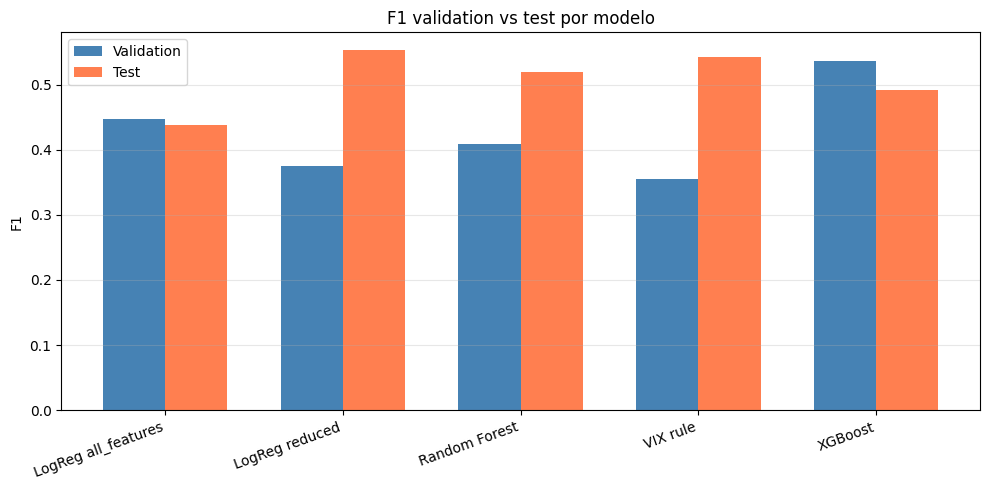

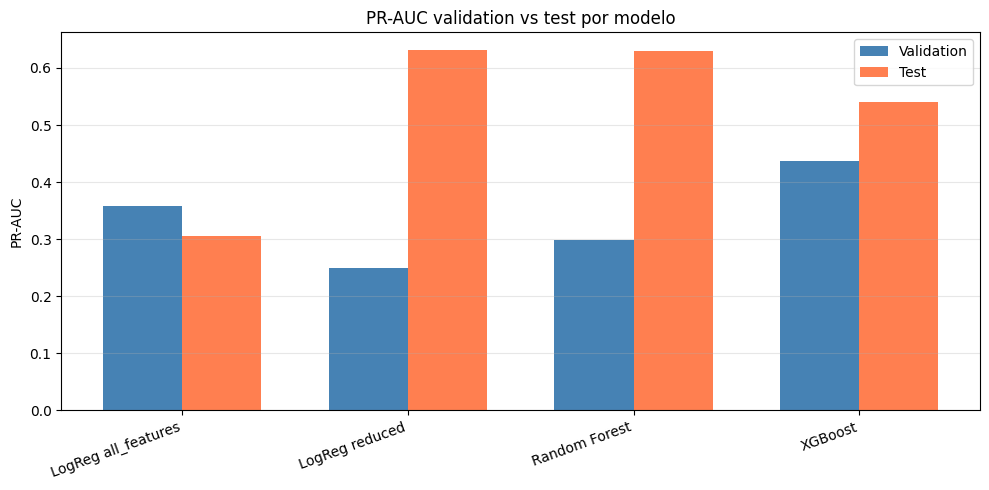

In [4]:
pivot_f1 = results_summary.pivot(index="modelo", columns="split", values="f1")
pivot_pr = results_summary.pivot(index="modelo", columns="split", values="pr_auc")

gap_rows = []
for model in pivot_f1.index:
    row = {"modelo": model}
    for metric in ["f1", "precision", "recall", "pr_auc"]:
        pv = results_summary.loc[results_summary["modelo"] == model].set_index("split")
        if metric == "pr_auc" and pv["pr_auc"].isna().all():
            continue
        if "test" in pv.index and "validation" in pv.index:
            row[f"delta_{metric}"] = pv.loc["test", metric] - pv.loc["validation", metric]
            row[f"{metric}_validation"] = pv.loc["validation", metric]
            row[f"{metric}_test"] = pv.loc["test", metric]
    gap_rows.append(row)

generalization_gap = pd.DataFrame(gap_rows)
generalization_gap.to_csv(REPORTS_TABLES / "validation_test_generalization_gap.csv", index=False)
display(generalization_gap.round(4))

# F1 validation vs test
fig, ax = plt.subplots(figsize=(10, 5))
models = pivot_f1.index.tolist()
x = np.arange(len(models))
w = 0.35
ax.bar(x - w/2, pivot_f1["validation"], w, label="Validation", color="steelblue")
ax.bar(x + w/2, pivot_f1["test"], w, label="Test", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylabel("F1")
ax.set_title("F1 validation vs test por modelo")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_FIGURES / "f1_validation_vs_test.png", dpi=150)
plt.show()

# PR-AUC validation vs test (modelos con PR-AUC)
pr_models = results_summary.dropna(subset=["pr_auc"])["modelo"].unique()
pr_val = [results_summary.query("modelo == @m and split == 'validation'")["pr_auc"].iloc[0] for m in pr_models]
pr_te = [results_summary.query("modelo == @m and split == 'test'")["pr_auc"].iloc[0] for m in pr_models]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pr_models))
ax.bar(x - w/2, pr_val, w, label="Validation", color="steelblue")
ax.bar(x + w/2, pr_te, w, label="Test", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(pr_models, rotation=20, ha="right")
ax.set_ylabel("PR-AUC")
ax.set_title("PR-AUC validation vs test por modelo")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_FIGURES / "prauc_validation_vs_test.png", dpi=150)
plt.show()


## PARTE 3 — Análisis de falsos positivos y falsos negativos

In [5]:
def train_and_predict(model_name, cfg):
    """Reentrena con config fija y devuelve predicciones/probas en val y test."""
    if cfg["kind"] == "vix":
        thr = cfg["threshold"]
        proba_val = df_val["vix"].values
        proba_test = df_test["vix"].values
        pred_val = (proba_val >= thr).astype(int)
        pred_test = (proba_test >= thr).astype(int)
        score_val = proba_val
        score_test = proba_test
        return pred_val, pred_test, score_val, score_test

    cols = FEATURE_VARIANTS[cfg["variant"]]
    X_tr, X_va, X_te = df_train[cols], df_val[cols], df_test[cols]
    thr = cfg["threshold"]

    if cfg["kind"] == "logreg":
        model = LogisticRegression(
            C=cfg["C"], solver="liblinear", penalty="l2",
            class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE,
        )
        model.fit(X_tr, y_train)
        proba_val = model.predict_proba(X_va)[:, 1]
        proba_test = model.predict_proba(X_te)[:, 1]
    elif cfg["kind"] == "rf":
        model = RandomForestClassifier(
            **cfg["params"], random_state=RANDOM_STATE, n_jobs=-1,
        )
        model.fit(X_tr, y_train)
        proba_val = model.predict_proba(X_va)[:, 1]
        proba_test = model.predict_proba(X_te)[:, 1]
    elif cfg["kind"] == "xgb":
        if not XGBOOST_AVAILABLE:
            raise RuntimeError("XGBoost no disponible")
        model = xgb.XGBClassifier(
            **cfg["params"], eval_metric="logloss", random_state=RANDOM_STATE,
            n_jobs=-1, scale_pos_weight=scale_pos_weight, use_label_encoder=False,
        )
        model.fit(X_tr, y_train)
        proba_val = model.predict_proba(X_va)[:, 1]
        proba_test = model.predict_proba(X_te)[:, 1]
    else:
        raise ValueError(cfg["kind"])

    pred_val = (proba_val >= thr).astype(int)
    pred_test = (proba_test >= thr).astype(int)
    return pred_val, pred_test, proba_val, proba_test


def error_table(y, pred, model, split):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    return {
        "modelo": model, "split": split,
        "n_pos_real": n_pos, "n_neg_real": n_neg,
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "fnr": fn / n_pos if n_pos else np.nan,
        "fpr": fp / n_neg if n_neg else np.nan,
        "alert_rate": pred.mean(),
    }

predictions = {}
error_rows = []

for name in ERROR_ANALYSIS_MODELS:
    cfg = MODEL_CONFIGS[name]
    pred_val, pred_test, score_val, score_test = train_and_predict(name, cfg)
    predictions[name] = {
        "pred_val": pred_val, "pred_test": pred_test,
        "score_val": score_val, "score_test": score_test,
    }
    error_rows.append(error_table(y_val, pred_val, name, "validation"))
    error_rows.append(error_table(y_test, pred_test, name, "test"))

error_analysis_summary = pd.DataFrame(error_rows)
error_analysis_summary.to_csv(REPORTS_TABLES / "error_analysis_summary.csv", index=False)
display(error_analysis_summary.round(4))

# Falsos negativos y positivos en test
context_cols = ["date", TARGET_COL, "vix", "sp500_return_20d", "sp500_drawdown_252d"]
context_cols = [c for c in context_cols if c in df_test.columns]

fn_rows, fp_rows = [], []
for name in ERROR_ANALYSIS_MODELS:
    pred = predictions[name]["pred_test"]
    score = predictions[name]["score_test"]
    for i, row in df_test.iterrows():
        idx = df_test.index.get_loc(i)
        y_t = int(y_test.iloc[idx])
        y_p = int(pred[idx])
        if y_t == 1 and y_p == 0:
            rec = {c: row[c] for c in context_cols}
            rec.update({"model": name, "y_true": y_t, "y_pred": y_p,
                        "probability_or_score": score[idx]})
            fn_rows.append(rec)
        elif y_t == 0 and y_p == 1:
            rec = {c: row[c] for c in context_cols}
            rec.update({"model": name, "y_true": y_t, "y_pred": y_p,
                        "probability_or_score": score[idx]})
            fp_rows.append(rec)

test_fn = pd.DataFrame(fn_rows)
test_fp = pd.DataFrame(fp_rows)
test_fn.to_csv(REPORTS_TABLES / "test_false_negatives_by_model.csv", index=False)
test_fp.to_csv(REPORTS_TABLES / "test_false_positives_by_model.csv", index=False)
print(f"FN test: {len(test_fn)} filas | FP test: {len(test_fp)} filas")
display(test_fn.groupby("model").size().rename("n_false_negatives"))
display(test_fp.groupby("model").size().rename("n_false_positives"))


,modelo,split,n_pos_real,n_neg_real,tp,fp,fn,tn,fnr,fpr,alert_rate
0,VIX rule,validation,136,850,56,123,80,727,0.5882,0.1447,0.1815
1,VIX rule,test,449,1111,374,557,75,554,0.1670,0.5014,0.5968
2,LogReg reduced,validation,136,850,116,567,20,283,0.1471,0.6671,0.6927
3,LogReg reduced,test,449,1111,432,934,17,177,0.0379,0.8407,0.8756
4,Random Forest,validation,136,850,70,136,66,714,0.4853,0.1600,0.2089
5,Random Forest,test,449,1111,368,599,81,512,0.1804,0.5392,0.6199
6,XGBoost,validation,136,850,73,63,63,787,0.4632,0.0741,0.1379
7,XGBoost,test,449,1111,225,240,224,871,0.4989,0.2160,0.2981


FN test: 397 filas | FP test: 2330 filas


model
LogReg reduced     17
Random Forest      81
VIX rule           75
XGBoost           224
Name: n_false_negatives, dtype: int64

model
LogReg reduced    934
Random Forest     599
VIX rule          557
XGBoost           240
Name: n_false_positives, dtype: int64

### Interpretación — errores de clasificación

- **Falsos negativos (FN):** no detectar riesgo futuro — costoso en gestión de exposición/capital.
- **Falsos positivos (FP):** alarmas innecesarias — coste operativo y fatiga de alertas.
- **VIX** y **LogReg reduced** suelen tener **menos FN** en test (alto recall) a cambio de más FP.
- **XGBoost** con threshold alto (0.83) tiende a **equilibrar** precision/recall en validation pero genera más FN en test.
- **Accuracy** es engañosa con **desbalance** (~29% positivos en test): un modelo que predice siempre "no riesgo" tendría accuracy ~71% con recall 0.


## PARTE 4 — Análisis temporal

modelo,LogReg reduced,Random Forest,VIX rule,XGBoost
year,,,,
2020,0.713,0.613,0.665,0.422
2021,0.091,0.000,0.060,0.000
2022,0.872,0.846,0.864,0.676
2023,0.192,0.217,0.160,0.092
2024,0.154,0.226,0.053,0.290
2025,0.424,0.371,0.446,0.506
2026,0.441,0.500,0.469,0.484


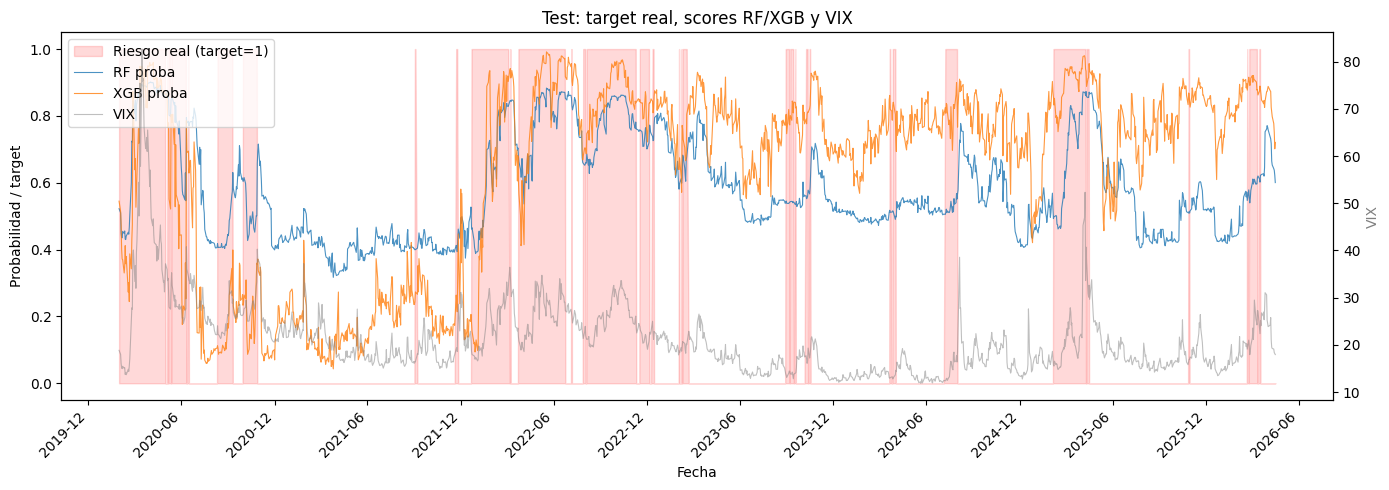

In [6]:
def metrics_by_year(dates, y, pred, model):
    df = pd.DataFrame({"date": dates, "y": y, "pred": pred})
    df["year"] = df["date"].dt.year
    rows = []
    for year, g in df.groupby("year"):
        if len(g) == 0:
            continue
        rows.append({
            "modelo": model, "year": int(year),
            "precision": precision_score(g["y"], g["pred"], zero_division=0),
            "recall": recall_score(g["y"], g["pred"], zero_division=0),
            "f1": f1_score(g["y"], g["pred"], zero_division=0),
            "n_pos_real": int((g["y"] == 1).sum()),
            "alert_rate": g["pred"].mean(),
            "n_days": len(g),
        })
    return rows

year_rows = []
for name in ERROR_ANALYSIS_MODELS:
    pred = predictions[name]["pred_test"]
    year_rows.extend(metrics_by_year(df_test["date"], y_test, pred, name))

test_metrics_by_year = pd.DataFrame(year_rows)
test_metrics_by_year.to_csv(REPORTS_TABLES / "test_metrics_by_year.csv", index=False)
display(test_metrics_by_year.pivot_table(index="year", columns="modelo", values="f1").round(3))

# Gráfico temporal: target, probas RF/XGB, VIX
rf_score = predictions["Random Forest"]["score_test"]
xgb_score = predictions["XGBoost"]["score_test"] if "XGBoost" in predictions else None
vix_test = df_test["vix"].values
target = y_test.values
dates = df_test["date"]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.fill_between(dates, 0, target, alpha=0.15, color="red", label="Riesgo real (target=1)")
ax1.plot(dates, rf_score, label="RF proba", alpha=0.8, linewidth=0.8)
if xgb_score is not None:
    ax1.plot(dates, xgb_score, label="XGB proba", alpha=0.8, linewidth=0.8)
ax1.set_ylabel("Probabilidad / target")
ax1.set_xlabel("Fecha")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(dates, vix_test, color="gray", alpha=0.5, linewidth=0.8, label="VIX")
ax2.set_ylabel("VIX", color="gray")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title("Test: target real, scores RF/XGB y VIX")
fig.tight_layout()
fig.savefig(REPORTS_FIGURES / "test_risk_scores_over_time.png", dpi=150)
plt.show()


### Interpretación — estabilidad temporal

- **2020** concentra muchos positivos reales; modelos con alto recall (VIX, LogReg reduced) capturan mejor el shock.
- **2022** (tipos, inflación) muestra otro régimen de volatilidad; rankings por año difieren del agregado.
- Periodos tranquilos (p.ej. tramos de 2021, 2024) penalizan modelos calibrados en validation pre-2020.
- **Test es más difícil y heterogéneo** que validation: más positivos, más cambios estructurales → evidencia de **no estacionariedad**.


## PARTE 5 — VIX como score continuo

In [7]:
def auc_from_score(y, score):
    return {
        "roc_auc": roc_auc_score(y, score),
        "pr_auc": average_precision_score(y, score),
    }

vix_auc_rows = []
for split_name, y, vix_s in [
    ("validation", y_val, df_val["vix"]),
    ("test", y_test, df_test["vix"]),
]:
    m = auc_from_score(y, vix_s)
    vix_auc_rows.append({"modelo": "VIX (score continuo)", "split": split_name, **m})

for split_name in ["validation", "test"]:
    for mname in ["Random Forest", "XGBoost"]:
        if mname not in predictions:
            continue
        key = "score_val" if split_name == "validation" else "score_test"
        y = y_val if split_name == "validation" else y_test
        sc = predictions[mname][key]
        vix_auc_rows.append({"modelo": mname, "split": split_name, **auc_from_score(y, sc)})

vix_score_auc = pd.DataFrame(vix_auc_rows)
vix_score_auc.to_csv(REPORTS_TABLES / "vix_score_auc_comparison.csv", index=False)
display(vix_score_auc.round(4))


,modelo,split,roc_auc,pr_auc
0,VIX (score continuo),validation,0.6888,0.2902
1,VIX (score continuo),test,0.7595,0.6032
2,Random Forest,validation,0.6199,0.2982
3,XGBoost,validation,0.7473,0.4363
4,Random Forest,test,0.7550,0.6290
5,XGBoost,test,0.6708,0.5400


### Interpretación — VIX como score

- El **VIX en niveles** ya tiene **PR-AUC competitivo** (especialmente en test), no solo como umbral discreto.
- RF y XGBoost deben **superar esta referencia simple** para justificar complejidad adicional.
- En test, el VIX continuo puede igualar o superar PR-AUC de XGBoost → refuerza su papel como **baseline financiero fuerte**.


## PARTE 6 — Interpretabilidad global

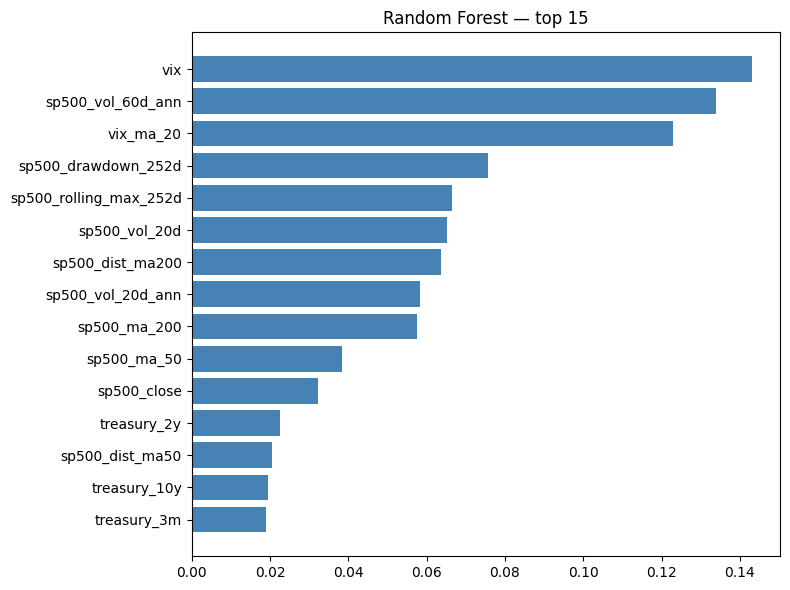

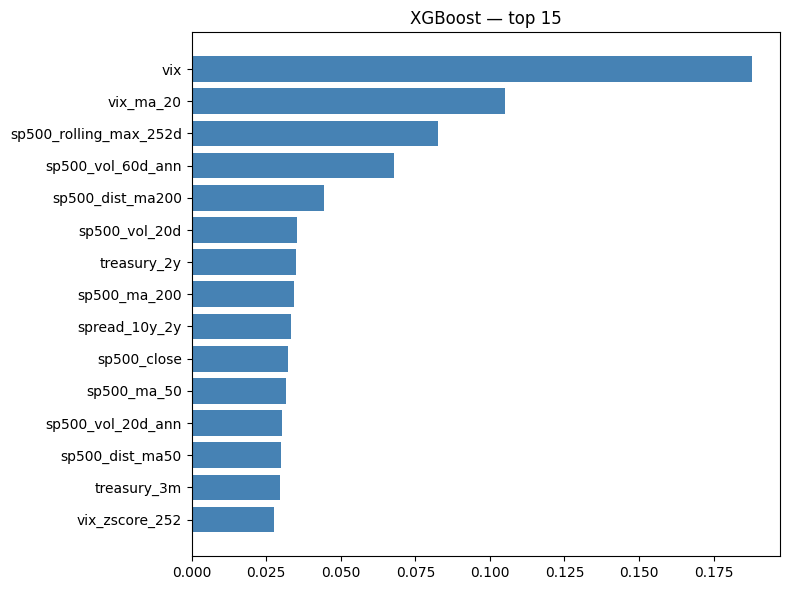

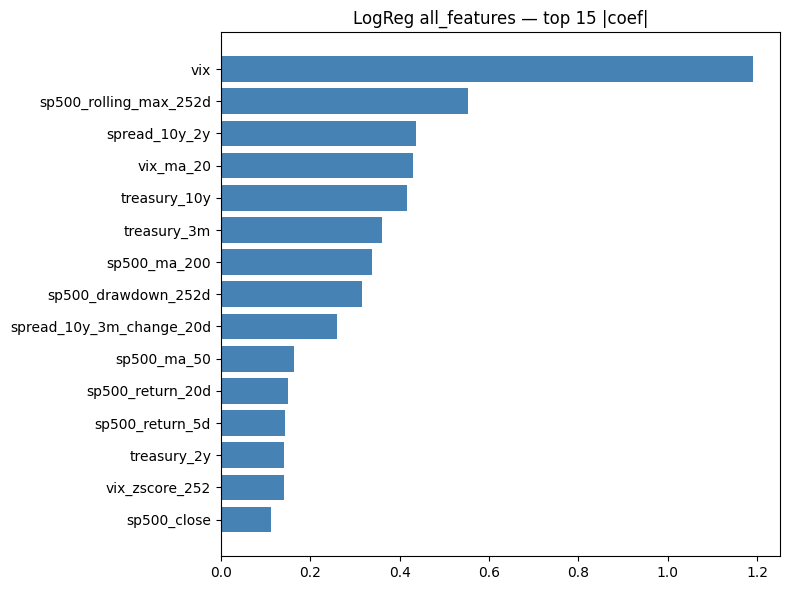

,variable,rank_rf,rank_xgb,rank_logreg_abs,family
23,vix,1.0,1.0,1.0,VIX
13,sp500_vol_60d_ann,2.0,4.0,21.0,volatilidad realizada
26,vix_ma_20,3.0,2.0,4.0,VIX
4,sp500_drawdown_252d,4.0,18.0,8.0,drawdown
10,sp500_rolling_max_252d,5.0,3.0,2.0,drawdown
11,sp500_vol_20d,6.0,6.0,26.0,volatilidad realizada
2,sp500_dist_ma200,7.0,5.0,22.0,tendencia/mercado
12,sp500_vol_20d_ann,8.0,12.0,27.0,volatilidad realizada
5,sp500_ma_200,9.0,8.0,7.0,tendencia/mercado
6,sp500_ma_50,10.0,11.0,10.0,tendencia/mercado


In [8]:
def feature_family(name: str) -> str:
    if name.startswith("vix"):
        return "VIX"
    if "drawdown" in name or "rolling_max" in name:
        return "drawdown"
    if "vol" in name:
        return "volatilidad realizada"
    if name.startswith("sp500_return") or name.startswith("sp500_dist") or name.startswith("sp500_ma"):
        return "tendencia/mercado"
    if "treasury" in name or "spread" in name or "curve" in name:
        return "tipos/curva"
    if name == "sp500_close":
        return "mercado"
    return "otros"

rf_imp = pd.read_csv(REPORTS_TABLES / "random_forest_feature_importance.csv")
xgb_imp = pd.read_csv(REPORTS_TABLES / "xgboost_feature_importance.csv")
logreg_coef = pd.read_csv(REPORTS_TABLES / "logreg_coefficients_best_model.csv")

for df_imp, col, title, fname in [
    (rf_imp, "importance", "Random Forest — top 15", "rf_top15_feature_importance.png"),
    (xgb_imp, "importance", "XGBoost — top 15", "xgb_top15_feature_importance.png"),
    (logreg_coef.sort_values("abs_coef", ascending=False), "abs_coef",
     "LogReg all_features — top 15 |coef|", "logreg_top15_coefficients.png"),
]:
    top = df_imp.head(15).sort_values(col)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top["feature"], top[col], color="steelblue")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(REPORTS_FIGURES / fname, dpi=150)
    plt.show()

# Ranking comparativo
def rank_series(s, ascending=False):
    return s.rank(ascending=ascending, method="min")

rf_r = rf_imp.set_index("feature")["importance"]
xgb_r = xgb_imp.set_index("feature")["importance"]
lr_r = logreg_coef.set_index("feature")["abs_coef"]

all_feats = sorted(set(rf_r.index) | set(xgb_r.index) | set(lr_r.index))
cmp_rows = []
for f in all_feats:
    cmp_rows.append({
        "variable": f,
        "rank_rf": rank_series(rf_r, False)[f] if f in rf_r.index else np.nan,
        "rank_xgb": rank_series(xgb_r, False)[f] if f in xgb_r.index else np.nan,
        "rank_logreg_abs": rank_series(lr_r, False)[f] if f in lr_r.index else np.nan,
        "family": feature_family(f),
    })

feature_importance_comparison = pd.DataFrame(cmp_rows).sort_values(
    ["rank_rf", "rank_xgb"], na_position="last"
)
feature_importance_comparison.to_csv(
    REPORTS_TABLES / "feature_importance_comparison.csv", index=False
)
display(feature_importance_comparison.head(20))


### Interpretación — variables globales

- Dominan señales de **VIX** y **volatilidad realizada** (`sp500_vol_*`, `vix_ma_20`).
- **Drawdown** y distancia a máximos aparecen en RF/XGB — coherente con el target (estrés futuro).
- **Tipos/spreads** tienen peso menor pero presente en LogReg (spreads, treasury) — señal macro secundaria.
- Las tres familias de modelos convergen en variables **financieramente interpretables**.


## PARTE 7 — SHAP para XGBoost (opcional)

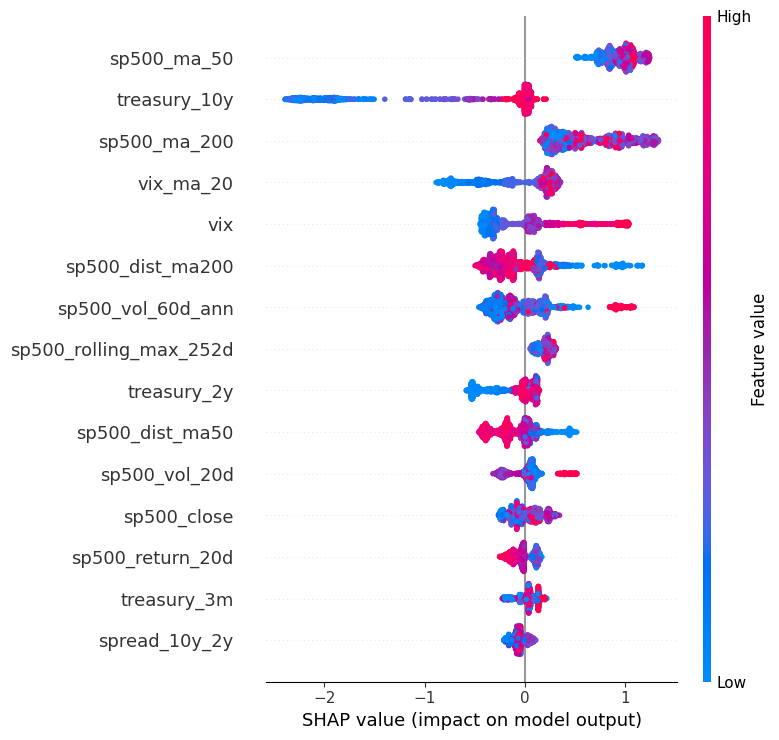

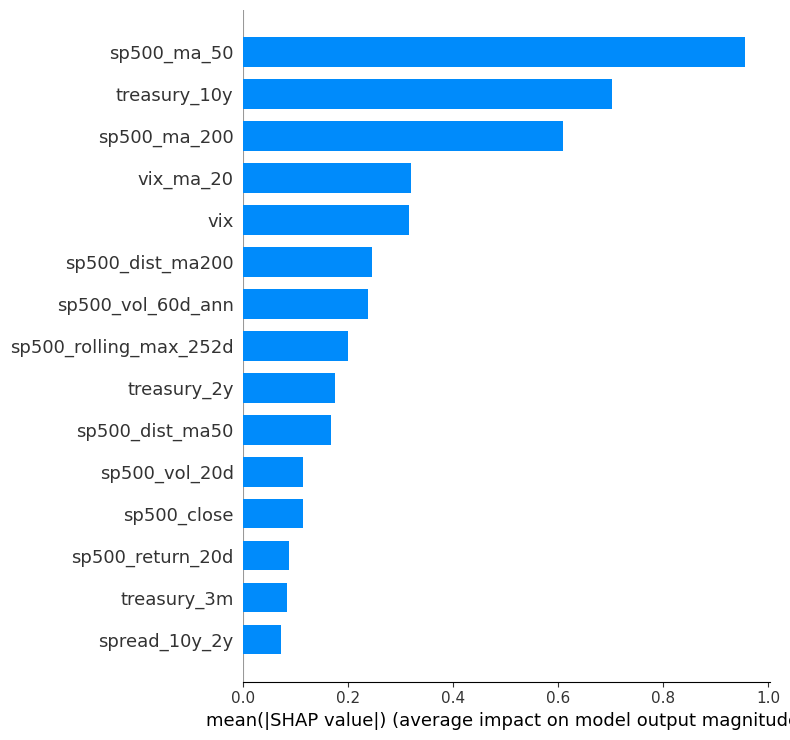

,date,case_type,y_true,y_pred,predicted_probability,top_positive_shap_features,top_negative_shap_features
0,2020-02-27,true_positive,1,1,0.873267,"[('vix', np.float32(0.91074187)), ('sp500_ma_5...","[('treasury_10y', np.float32(-2.1052234)), ('s..."
1,2020-05-01,false_positive,0,1,0.863832,"[('sp500_vol_60d_ann', np.float32(1.0629685)),...","[('treasury_10y', np.float32(-1.8628159)), ('t..."
2,2020-01-31,false_negative,1,0,0.544847,"[('sp500_ma_50', np.float32(1.1186285)), ('sp5...","[('treasury_10y', np.float32(-1.9405683)), ('v..."


In [9]:
if not SHAP_AVAILABLE:
    print("SHAP no instalado. Instalar con: pip install shap")
else:
    cols = FEATURE_VARIANTS["all_features"]
    X_tr = df_train[cols]
    X_te = df_test[cols]
    cfg = MODEL_CONFIGS["XGBoost"]

    xgb_model = xgb.XGBClassifier(
        **cfg["params"], eval_metric="logloss", random_state=RANDOM_STATE,
        n_jobs=-1, scale_pos_weight=scale_pos_weight, use_label_encoder=False,
    )
    xgb_model.fit(X_tr, y_train)

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_te)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_te, show=False, max_display=15)
    plt.tight_layout()
    plt.savefig(REPORTS_FIGURES / "xgb_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_global = pd.DataFrame({"feature": cols, "mean_abs_shap": mean_abs})
    shap_global = shap_global.sort_values("mean_abs_shap", ascending=False)
    shap_global.to_csv(REPORTS_TABLES / "xgb_shap_global_importance.csv", index=False)

    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_values, X_te, plot_type="bar", show=False, max_display=15)
    plt.tight_layout()
    plt.savefig(REPORTS_FIGURES / "xgb_shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Casos locales en test
    proba_te = xgb_model.predict_proba(X_te)[:, 1]
    pred_te = (proba_te >= cfg["threshold"]).astype(int)

    def pick_case(mask, label):
        idxs = np.where(mask)[0]
        if len(idxs) == 0:
            return None
        i = idxs[0]
        sv = shap_values[i]
        order = np.argsort(sv)
        top_neg = [(cols[j], sv[j]) for j in order[:3]]
        top_pos = [(cols[j], sv[j]) for j in order[-3:][::-1]]
        return {
            "date": df_test["date"].iloc[i].strftime("%Y-%m-%d"),
            "case_type": label,
            "y_true": int(y_test.iloc[i]),
            "y_pred": int(pred_te[i]),
            "predicted_probability": float(proba_te[i]),
            "top_positive_shap_features": str(top_pos),
            "top_negative_shap_features": str(top_neg),
        }

    cases = []
    for label, mask in [
        ("true_positive", (y_test.values == 1) & (pred_te == 1)),
        ("false_positive", (y_test.values == 0) & (pred_te == 1)),
        ("false_negative", (y_test.values == 1) & (pred_te == 0)),
    ]:
        c = pick_case(mask, label)
        if c:
            cases.append(c)

    xgb_shap_local = pd.DataFrame(cases)
    xgb_shap_local.to_csv(REPORTS_TABLES / "xgb_shap_local_examples.csv", index=False)
    display(xgb_shap_local)


### SHAP — notas de interpretación

- Si SHAP no está instalado: `pip install shap` y re-ejecutar esta sección.
- Variables con SHAP positivo alto en **verdaderos positivos** suelen ser VIX/volatilidad elevados.
- **Falsos positivos:** el modelo ve estrés en indicadores de volatilidad aunque el target a 20 días no se materialice.
- **Falsos negativos:** señales insuficientes en features observables — riesgo "oculto" o cambio de régimen.
- SHAP describe **contribución al modelo**, no causalidad económica.


## PARTE 8 — Conclusiones del Notebook 06

1. **El mejor modelo en validation (XGBoost) no es el mejor en test** — la selección out-of-time es frágil.
2. **VIX** es un baseline financiero muy fuerte, tanto como regla discreta como score continuo (PR-AUC).
3. **Modelos no lineales** aportan ranking probabilístico (RF destaca en PR-AUC test), pero thresholds calibrados en validation **degradan** en test.
4. La brecha validation→test evidencia **no estacionariedad / cambio de régimen** (pre-2020 vs 2020+).
5. **Errores según coste:** FN = no detectar riesgo; FP = exceso de alertas. Accuracy no basta con clases desbalanceadas.
6. **Variables importantes** coherentes: VIX, volatilidad realizada, drawdown; tipos/spreads con peso secundario.
7. **Siguiente paso:** sensibilidad del target en **`notebooks/07_target_sensitivity_robustness.ipynb`** (análisis complementario).
